# Primetrade.ai Round-0 Assignment (Detailed)

**Title:** Trader Performance vs Market Sentiment  
**Candidate Task:** Analyze how Fear/Greed sentiment affects trader behavior and outcomes.

---

## Checklist Mapping to Prompt

### Part A - Data Preparation
- Load both datasets
- Document rows/columns, missing values, duplicates
- Convert timestamps and align on daily dates
- Create key metrics: daily PnL, win rate, avg trade size, leverage distribution/proxy, trades/day, long-short ratio

### Part B - Analysis
- Compare Fear vs Greed performance (PnL, win rate, drawdown proxy)
- Compare behavior shifts (trade frequency, leverage proxy, long/short bias, trade size)
- Segment traders (high/low leverage, frequent/infrequent, consistent/inconsistent)
- Provide >= 3 evidence-backed insights with charts/tables

### Part C - Actionable Output
- Provide at least 2 strategy ideas (rules of thumb)

All outputs are generated and stored in `output/`.

## 1) Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from analyze_trader_sentiment import (
    ensure_dirs,
    load_data,
    clean_sentiment,
    clean_trades,
    dataset_quality_report,
    build_daily_account_metrics,
    join_daily_with_sentiment,
    alignment_report,
    sentiment_comparison,
    sentiment_difference_evidence,
    build_segments,
    segment_performance_tables,
    save_charts,
    build_report,
    OUTPUT_DIR,
    TABLE_DIR,
    CHART_DIR,
)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")

## 2) Load Raw Datasets (Part A)

In [2]:
ensure_dirs()
sentiment_raw, trades_raw = load_data()

print('Sentiment raw shape:', sentiment_raw.shape)
print('Trades raw shape   :', trades_raw.shape)

print('\nSentiment columns:', list(sentiment_raw.columns))
print('\nTrades columns:', list(trades_raw.columns))

Sentiment raw shape: (2644, 4)
Trades raw shape   : (211224, 16)

Sentiment columns: ['timestamp', 'value', 'classification', 'date']

Trades columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [3]:
sentiment_raw.head(3), trades_raw.head(3)

(    timestamp  value classification        date
 0  1517463000     30           Fear  2018-02-01
 1  1517549400     15   Extreme Fear  2018-02-02
 2  1517635800     40           Fear  2018-02-03,
                                       Account  Coin  Execution Price  Size Tokens   Size USD Side     Timestamp IST  Start Position Direction  Closed PnL  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769     986.8700 7,872.1600  BUY  02-12-2024 22:50          0.0000       Buy      0.0000   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800      16.0000   127.6800  BUY  02-12-2024 22:50        986.5246       Buy      0.0000   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855     144.0900 1,150.6300  BUY  02-12-2024 22:50      1,002.5190       Buy      0.0000   
 
                                     Transaction Hash     Order ID  Crossed    Fee                 Trade ID              Timestamp  
 0  0xec09451986a1874e3a980418412fcd

## 3) Data Cleaning + Quality Checks (Part A)

- Standardize column names
- Parse/convert timestamps
- Create date fields for daily alignment
- Compute missing and duplicate summaries

In [4]:
sentiment = clean_sentiment(sentiment_raw)
trades = clean_trades(trades_raw)

quality = dataset_quality_report(sentiment, trades)
quality

,dataset,rows,columns,missing_cells,duplicate_rows
0,sentiment,2644,4,0,0
1,trades,211224,24,0,0


In [5]:
print('Cleaned sentiment shape:', sentiment.shape)
print('Cleaned trades shape   :', trades.shape)

print('\nSentiment dtypes:\n', sentiment.dtypes)
print('\nTrades key dtypes:\n', trades[['trade_datetime','trade_date','closed_pnl','size_usd','effective_leverage']].dtypes)

Cleaned sentiment shape: (2644, 4)
Cleaned trades shape   : (211224, 24)

Sentiment dtypes:
 date                object
classification         str
value                int64
sentiment_bucket       str
dtype: object

Trades key dtypes:
 trade_datetime        datetime64[us]
trade_date                    object
closed_pnl                   float64
size_usd                     float64
effective_leverage           float64
dtype: object


## 4) Daily Alignment by Date (Part A)

In [7]:
daily = build_daily_account_metrics(trades)
merged = join_daily_with_sentiment(daily, sentiment)
align = alignment_report(sentiment, trades, merged)

print('Daily account metrics shape:', daily.shape)
print('Merged account-day shape   :', merged.shape)
align

Daily account metrics shape: (2341, 16)
Merged account-day shape   : (2340, 20)


,sentiment_unique_dates,trade_unique_dates,overlap_dates,sentiment_only_dates,trade_only_dates,merged_rows_account_day
0,2644,480,479,2165,1,2340


In [8]:
merged[['trade_date','account','daily_pnl','win_rate','trades_per_day','avg_trade_size_usd','avg_effective_leverage','long_short_ratio','sentiment_bucket']].head(10)

,trade_date,account,daily_pnl,win_rate,trades_per_day,avg_trade_size_usd,avg_effective_leverage,long_short_ratio,sentiment_bucket
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.0000,0.0000,3,159.0000,61.5932,4.0000,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.0000,0.0000,9,"5,556.2033",196.8740,2.6667,Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.4347,0.3636,11,"10,291.2136","1,394.4639",0.8571,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.6320,0.0000,2,"5,304.9750",0.8141,3.0000,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.0000,0.0000,3,"5,116.2567","1,560.5925",4.0000,Greed
5,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,304.9828,0.5000,14,"8,305.5729","2,909.1439",0.3333,Greed
6,2023-12-18,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.0000,0.0000,2,"15,582.0900",853.8400,3.0000,Greed
7,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,"1,000.5386",0.6667,15,"6,106.8273",314.9270,0.5455,Greed
8,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,162.7323,0.4444,18,"7,868.7106","1,193.3203",1.2222,Greed
9,2023-12-21,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,537.2114,0.5306,49,"2,555.7953",186.9897,0.8214,Greed


## 5) Key Metrics Created (Part A)

This assignment-required metric set is now available in `daily` and `merged`:

- `daily_pnl` (daily PnL per trader/account)
- `win_rate` and `loss_rate`
- `avg_trade_size_usd`, `gross_volume_usd`
- `trades_per_day`
- `long_short_ratio`
- `avg_effective_leverage` (direct leverage if available, else risk proxy)
- `drawdown_proxy`

In [9]:
metric_preview_cols = [
    'daily_pnl','win_rate','loss_rate','avg_trade_size_usd','gross_volume_usd',
    'trades_per_day','long_short_ratio','avg_effective_leverage','drawdown_proxy'
]
daily[metric_preview_cols].describe(percentiles=[0.25,0.5,0.75,0.9,0.95]).T

,count,mean,std,min,25%,50%,75%,90%,95%,max
daily_pnl,"2,341.0000","4,398.5301","28,415.9390","-358,963.1400",0.0000,207.9835,"1,842.8399","7,848.0000","19,573.8302","533,974.6629"
win_rate,"2,341.0000",0.3599,0.3436,0.0000,0.0000,0.3182,0.6080,0.9478,1.0000,1.0000
loss_rate,"2,341.0000",0.0651,0.1781,0.0000,0.0000,0.0000,0.0154,0.2000,0.4286,1.0000
avg_trade_size_usd,"2,341.0000","6,989.5153","21,538.6917",0.0000,695.2510,"1,914.0000","7,051.0058","18,749.7050","27,220.1276","844,654.1900"
gross_volume_usd,"2,341.0000","508,837.0109","2,413,745.0296",0.0000,"15,764.0100","69,357.3900","250,781.1800","802,803.8700","1,550,608.0700","51,250,451.4400"
trades_per_day,"2,341.0000",90.2281,214.6118,1.0000,9.0000,29.0000,80.0000,211.0000,358.0000,"4,083.0000"
long_short_ratio,"2,341.0000",6.6416,28.0685,0.0013,0.3333,0.9500,3.0000,12.0000,26.0000,564.0000
avg_effective_leverage,"2,341.0000",707.8258,"4,590.0296",0.0000,0.1209,11.5218,191.4396,"1,205.8765","2,212.8841","100,176.1000"
drawdown_proxy,"2,341.0000",-959.5870,"10,368.6896","-358,963.1400",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 6) Fear vs Greed - Performance Comparison (Part B)

In [10]:
comparison = sentiment_comparison(merged)
comparison

,sentiment_bucket,avg_daily_pnl,median_daily_pnl,avg_win_rate,avg_drawdown_proxy,avg_trades_per_day,avg_trade_size_usd,avg_buy_ratio,avg_long_short_ratio,avg_effective_leverage,avg_gross_volume_usd,accounts_days
0,Fear,"5,185.1464",122.7370,0.3571,"-1,101.4499",105.3633,"8,529.8598",0.5215,8.2192,552.9303,"756,720.3180",790
1,Greed,"4,144.2083",265.2477,0.3627,-926.1595,76.9123,"5,954.6326",0.4723,5.7080,616.7206,"351,829.3520",1174
2,Neutral,"3,438.6188",167.5517,0.3554,-768.4482,100.2287,"6,963.6949",0.4724,6.2409,"1,319.6136","479,367.1890",376


In [11]:
evidence = sentiment_difference_evidence(merged)
evidence

,metric,fear_mean,greed_mean,difference_greed_minus_fear,pct_change_vs_fear,permutation_p_value
0,daily_pnl,"5,185.1464","4,144.2083","-1,040.9381",-20.0754,0.4553
1,win_rate,0.3571,0.3627,0.0057,1.5899,0.7136
2,drawdown_proxy,"-1,101.4499",-926.1595,175.2904,15.9145,0.7736
3,trades_per_day,105.3633,76.9123,-28.4510,-27.0028,0.0020
4,avg_trade_size_usd,"8,529.8598","5,954.6326","-2,575.2272",-30.1907,0.0030
5,long_short_ratio,8.2192,5.7080,-2.5112,-30.5528,0.0580
6,avg_effective_leverage,552.9303,616.7206,63.7903,11.5368,0.7081


### Interpretation (Part B - Performance)

- Compare `daily_pnl`, `win_rate`, and `drawdown_proxy` between Fear and Greed rows above.
- `difference_greed_minus_fear` and `pct_change_vs_fear` quantify regime shift direction and magnitude.
- `permutation_p_value` provides a simple non-parametric significance signal.

## 7) Behavior Shift Analysis (Part B)

Behavioral metrics requested in prompt:
- trade frequency: `trades_per_day`
- leverage: `avg_effective_leverage`
- long/short bias: `long_short_ratio`
- position size: `avg_trade_size_usd`

In [14]:
behavior_metrics = ['trades_per_day','avg_effective_leverage','long_short_ratio','avg_trade_size_usd']
behavior_table = evidence[evidence['metric'].isin(behavior_metrics)].copy()
behavior_table

,metric,fear_mean,greed_mean,difference_greed_minus_fear,pct_change_vs_fear,permutation_p_value
3,trades_per_day,105.3633,76.9123,-28.4510,-27.0028,0.0020
4,avg_trade_size_usd,"8,529.8598","5,954.6326","-2,575.2272",-30.1907,0.0030
5,long_short_ratio,8.2192,5.7080,-2.5112,-30.5528,0.0580
6,avg_effective_leverage,552.9303,616.7206,63.7903,11.5368,0.7081


## 8) Trader Segmentation (Part B)

Required segments implemented:
- High leverage vs Low leverage
- Frequent vs Infrequent
- Consistent winners vs Inconsistent

In [16]:
profile = build_segments(merged)
seg_perf = segment_performance_tables(merged, profile)

print('Number of unique traders segmented:', profile['account'].nunique())
profile.head(10)

Number of unique traders segmented: 32


,account,avg_daily_pnl,total_pnl,avg_trades_per_day,avg_trade_size_usd,avg_gross_volume_usd,avg_effective_leverage,avg_win_rate,pnl_std,active_days,positive_day_ratio,frequency_segment,leverage_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,"66,676.2425","1,600,229.8200",159.0833,"33,569.1022","2,570,719.3321","3,937.3771",0.3523,"150,401.7973",24,0.6667,Frequent,High Leverage,Consistent Winners
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,920.8715,"47,885.3205",140.0000,"4,359.8309","231,451.6858","1,127.4702",0.3971,"3,603.0423",52,0.5577,Frequent,High Leverage,Inconsistent
2,0x271b280974205ca63b716753467d5a371de622ab,"-5,869.6826","-70,436.1913",317.4167,"11,057.1184","2,822,786.7017","1,709.1203",0.3800,"33,420.4100",12,0.6667,Frequent,High Leverage,Consistent Winners
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,817.6840,"132,464.8146",82.1667,484.8443,"41,710.0130",25.5581,0.4525,"2,993.2847",162,0.8889,Frequent,Low Leverage,Consistent Winners
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,"2,444.3189","168,658.0050",46.9420,"2,553.7570","147,346.0899",248.6516,0.4987,"4,867.7435",69,0.7826,Infrequent,Low Leverage,Consistent Winners
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-725.6651,"-31,203.6000",18.9535,"1,613.2557","32,788.4186",30.6190,0.2662,"10,110.2809",43,0.3256,Infrequent,Low Leverage,Inconsistent
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,314.2809,"14,456.9193",78.0217,"28,188.5491","373,769.0309","2,999.6885",0.3647,"14,586.4828",46,0.5435,Frequent,High Leverage,Inconsistent
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,"1,910.5803","53,496.2472",11.8571,"9,812.5156","40,853.4450","3,040.0492",0.4569,"5,774.4685",28,0.5357,Infrequent,High Leverage,Inconsistent
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,"9,975.2796","199,505.5927",19.1500,"8,334.7623","99,376.3805",238.7152,0.4300,"20,797.3960",20,0.5000,Infrequent,Low Leverage,Inconsistent
9,0x430f09841d65beb3f27765503d0f850b8bce7713,"14,876.4954","416,541.8723",44.1786,"2,525.9460","105,932.4721",269.4552,0.2027,"32,725.0833",28,0.2500,Infrequent,Low Leverage,Inconsistent


In [18]:
seg_summary = profile.groupby(['frequency_segment','leverage_segment','consistency_segment'], as_index=False).agg(
    traders=('account','count'),
    mean_daily_pnl=('avg_daily_pnl','mean'),
    mean_win_rate=('avg_win_rate','mean'),
    mean_trades_day=('avg_trades_per_day','mean')
).sort_values('traders', ascending=False)

seg_summary.head(12)

,frequency_segment,leverage_segment,consistency_segment,traders,mean_daily_pnl,mean_win_rate,mean_trades_day
0,Frequent,High Leverage,Consistent Winners,7,"13,979.0452",0.4376,161.6139
7,Infrequent,Low Leverage,Inconsistent,7,"4,583.9051",0.3076,31.5021
5,Infrequent,High Leverage,Inconsistent,5,"3,626.2175",0.2917,30.6809
2,Frequent,Low Leverage,Consistent Winners,5,"8,538.1272",0.3797,295.1591
6,Infrequent,Low Leverage,Consistent Winners,3,"1,825.1379",0.4012,42.2821
1,Frequent,High Leverage,Inconsistent,3,"2,755.7720",0.3217,129.1924
3,Frequent,Low Leverage,Inconsistent,1,"22,597.6614",0.2034,83.6842
4,Infrequent,High Leverage,Consistent Winners,1,962.5417,0.3012,23.6262


In [19]:
seg_perf.sort_values('observations', ascending=False).head(12)

,sentiment_bucket,frequency_segment,leverage_segment,consistency_segment,mean_pnl,mean_win_rate,mean_trades,observations
10,Greed,Frequent,Low Leverage,Consistent Winners,"3,712.3316",0.3761,163.1901,263
13,Greed,Infrequent,High Leverage,Inconsistent,"7,330.4310",0.2764,36.9417,240
2,Fear,Frequent,Low Leverage,Consistent Winners,"4,936.2778",0.3678,208.4271,199
12,Greed,Infrequent,High Leverage,Consistent Winners,"1,062.4549",0.2771,24.3878,196
8,Greed,Frequent,High Leverage,Consistent Winners,"4,853.2925",0.5835,88.0331,151
14,Greed,Infrequent,Low Leverage,Consistent Winners,"2,322.6908",0.4053,63.4380,137
7,Fear,Infrequent,Low Leverage,Inconsistent,"3,579.9764",0.2977,34.6912,136
0,Fear,Frequent,High Leverage,Consistent Winners,"16,129.7829",0.4878,158.8346,133
15,Greed,Infrequent,Low Leverage,Inconsistent,"1,685.6392",0.3202,36.3417,120
5,Fear,Infrequent,High Leverage,Inconsistent,"4,224.4744",0.3099,46.5138,109


## 9) Charts (Evidence for Part B)

In [20]:
save_charts(merged, comparison, profile)
print('Charts saved to:', CHART_DIR)

Charts saved to: C:\Users\hp\Downloads\internshala\output\charts


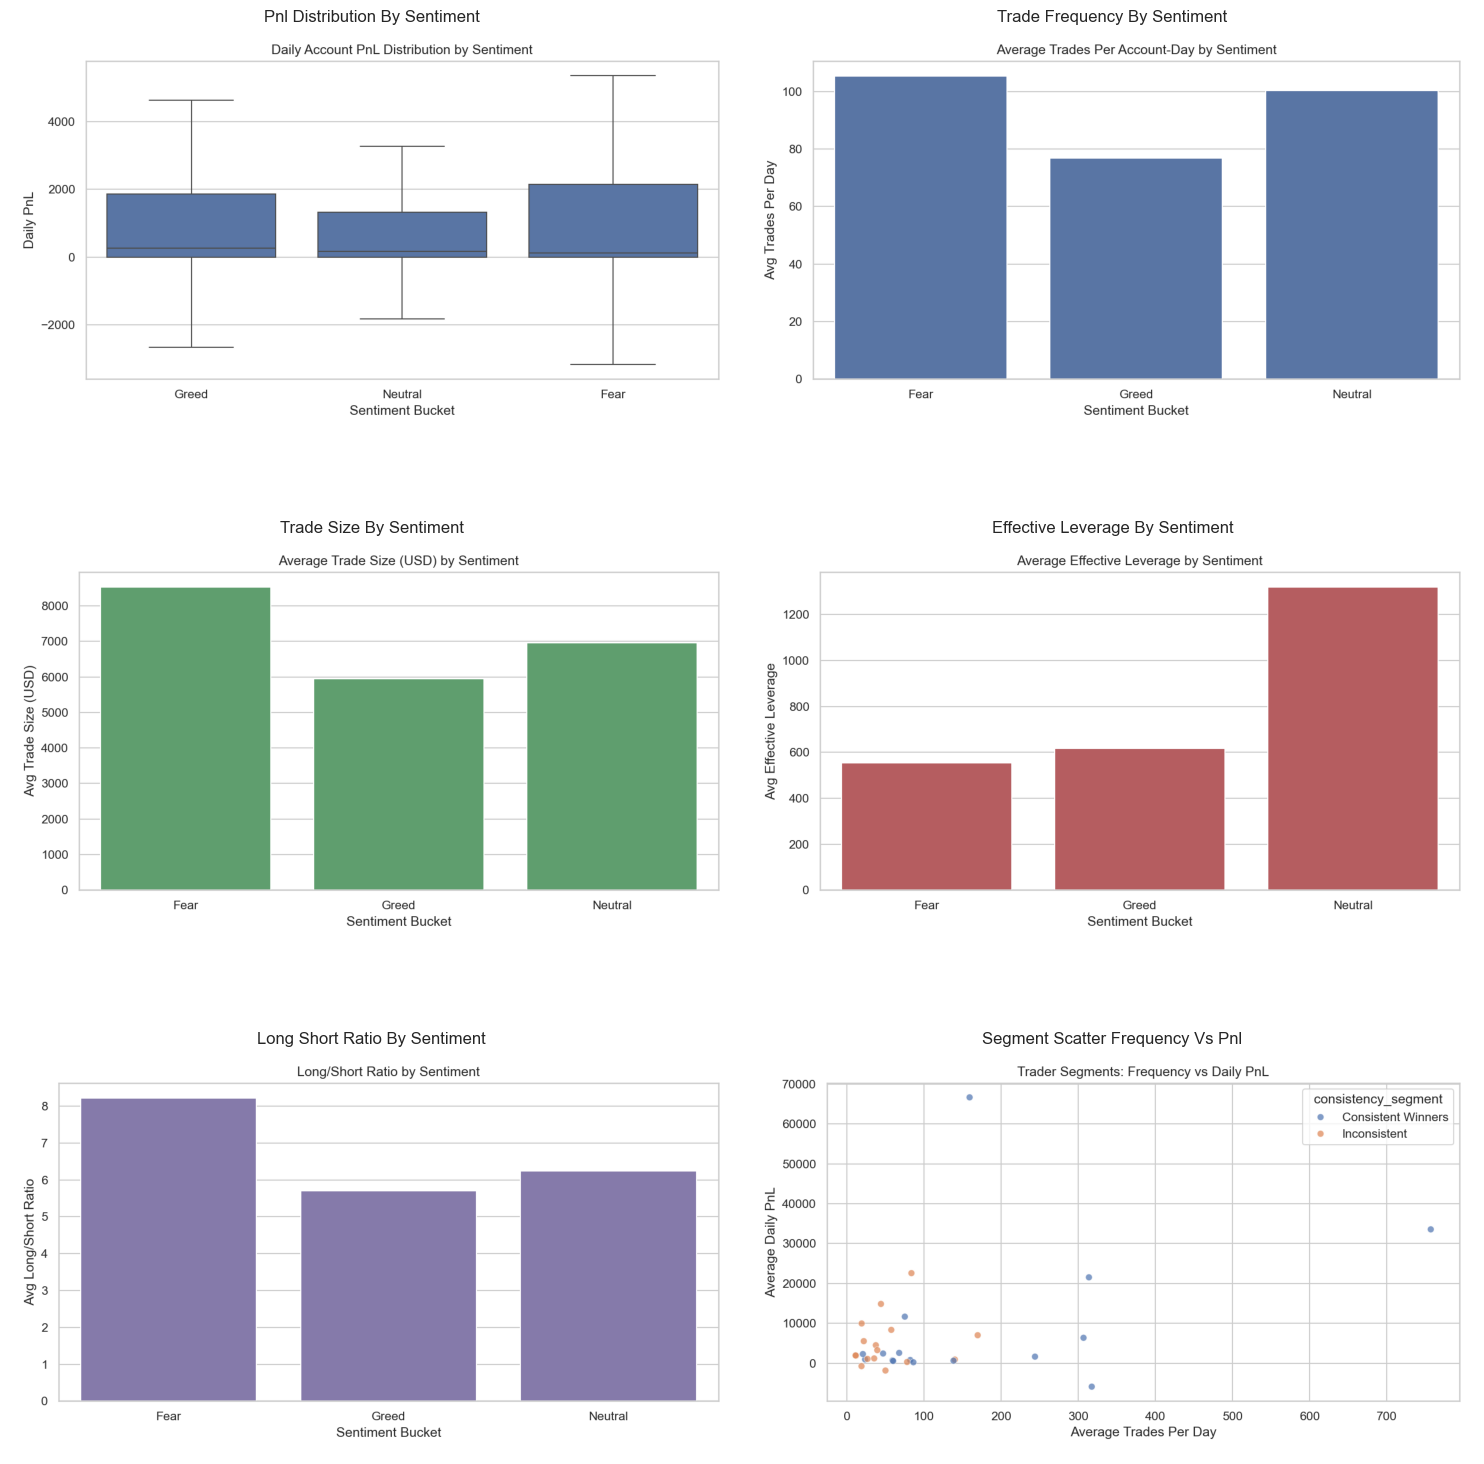

In [21]:
chart_files = [
    'pnl_distribution_by_sentiment.png',
    'trade_frequency_by_sentiment.png',
    'trade_size_by_sentiment.png',
    'effective_leverage_by_sentiment.png',
    'long_short_ratio_by_sentiment.png',
    'segment_scatter_frequency_vs_pnl.png',
]

fig, axes = plt.subplots(3, 2, figsize=(15, 16))
for ax, name in zip(axes.flatten(), chart_files):
    img = mpimg.imread(CHART_DIR / name)
    ax.imshow(img)
    ax.set_title(name.replace('_',' ').replace('.png','').title())
    ax.axis('off')
plt.tight_layout()
plt.show()

## 10) Three Evidence-Backed Insights (Part B)

1. **Performance regime effect:** Fear and Greed differ in average PnL/win-rate/drawdown profile (see `comparison` + `evidence`).  
2. **Behavioral adaptation:** Trade frequency and average size vary materially between sentiment regimes; leverage and long/short balance also shift.  
3. **Segment heterogeneity:** Frequent/consistent segments and leverage groups have distinct payoff and stability patterns (see `seg_summary` and `seg_perf`).

## 11) Actionable Output (Part C)

### Strategy Idea 1 - Regime-Aware Risk Scaling
- On **Fear** days, reduce position size and tighten stop-loss policy for low-consistency and low-quality segments.
- Keep risk budget dynamic using recent sentiment state.

### Strategy Idea 2 - Selective Aggression on Greed
- Increase trade frequency only for **consistent-winner** segments where expectancy is positive.
- Avoid blanket leverage increase for inconsistent segments despite optimistic sentiment.

In [22]:
report_text = build_report(quality, align, comparison, evidence, profile, seg_perf)
(OUTPUT_DIR / 'assignment_report.md').write_text(report_text, encoding='utf-8')

print('Detailed report generated at:', OUTPUT_DIR / 'assignment_report.md')
print('Tables folder:', TABLE_DIR)
print('Charts folder:', CHART_DIR)

Detailed report generated at: C:\Users\hp\Downloads\internshala\output\assignment_report.md
Tables folder: C:\Users\hp\Downloads\internshala\output\tables
Charts folder: C:\Users\hp\Downloads\internshala\output\charts


## 12) Submission Files

Include these in GitHub/Drive submission:
- `assignment_detailed.ipynb` (this notebook)
- `analyze_trader_sentiment.py`
- `README.md`
- `output/tables/*.csv`
- `output/charts/*.png`
- `output/assignment_report.md`